# Role-aware IAF vs. Full-Attention Affine Flow

This notebook compares the two retained posterior transports under the same grouped DSS-LVR model.

- **Shallow BNN:** \(n=240,\ p=6\), active predictors \(x_0,x_3\), two teacher units, five fitted units. Feature-group selection is used so the two active structural targets are identifiable. A matched multi-chain MCMC reference is fit once and reused by both VI methods.
- **MLP:** the same data-generating truth is fit with a stacked \(5\times5\) MLP using feature + unit groups with induced edges. No MCMC is used.
- **Full attention:** established affine coupling configuration with \(K=4\) coupling cycles.
- **Role-aware IAF:** \(K=6\) affine IAF layers, i.e. two repetitions of
  \(U\prec V\prec\tau\), \(V\prec\tau\prec U\), \(\tau\prec U\prec V\).

Both methods use the same data split, prior, decoder, normalized-ReQU structural map, warmup, optimization budget, and posterior sample size. The final shallow cell draws the joint posterior density of the two true active feature groups.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

%load_ext autoreload
%autoreload 2

import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from IPython.display import display

import Python.config as cfg
import Python.utils as ut
import Python.simfun as sim
import Python.model2 as md
import Python.bnn_metric as bm
import Python.bnn_mcmc as mcmc
import Python.bnn_train as train

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seed = 123

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 220)

print("device:", device)

device: cpu


In [8]:
# Formal settings. Set QUICK=True only for a smoke test.
QUICK = False

data_cfg = dict(
    n=240,
    p=6,
    active_features=(0, 3),
    n_true_units=2,
    fit_units=5,
    repu_power=None,
    sigma2=1.0,
    target_signal_sd=1.5,
    seed=seed,
    device=device,
)

flow_specs = {
    "Full attention": dict(flow_type="attention", K_flow=6),
    "Role-aware IAF": dict(flow_type="iaf", K_flow=6),
}

fit_cfg = dict(
    epochs=2000,
    warmup_epochs=500,
    lr=3e-4,
    R_train=100,
    R_eval=500,
    R_final=5000,
    eval_every=500,
    init_sd=0.5,
    init_loc_jitter=0.05,
    scale_clip=1.5,
    flow_hidden_units=128,
    flow_hidden_layers=2,
    flow_token_dim=32,
    flow_num_heads=4,
    sampling_timing_repeats=3,
)

mcmc_cfg = dict(
    n_chains=2,
    N=5000,
    burnin=1000,
    thin=1,
    S_max=100,
    print_every=None,
)

if QUICK:
    fit_cfg.update(
        epochs=120,
        warmup_epochs=30,
        R_train=16,
        R_eval=64,
        R_final=256,
        eval_every=60,
        sampling_timing_repeats=1,
    )
    mcmc_cfg.update(
        n_chains=2,
        N=160,
        burnin=40,
        S_max=40,
    )

In [3]:
# One dataset and one train/validation/test split are reused everywhere.
X, y, feature_true, unit_true, signal, info = sim.simfun_grouped_bnn(**data_cfg)

split_cfg = cfg.SplitConfig(
    train_frac=0.60,
    val_frac=0.20,
    test_frac=0.20,
    seed=seed + 1000,
)
indices = ut.make_split(X.shape[0], split_cfg)

splits = ut.split_data(X, y, indices, mode="tensor")
signal_splits = ut.split_data(X, signal, indices, mode="tensor")

print("truth active features:", info["active_idx"].tolist())
print("teacher units:", info["n_true_units"])

truth active features: [0, 3]
teacher units: 2


## Shallow BNN: matched MCMC reference

The shallow comparison uses `feature_group` with `hidden_dims=(5,)`. This gives two fixed truth-active structural targets, \(x_0\) and \(x_3\), so the VI--MCMC density comparison is not affected by hidden-unit label exchangeability.

In [6]:
reference_model = md.GroupedBNNVI(
    X=splits["X_train"],
    y=splits["y_train"],
    input_dim=6,
    hidden_dims=(5,),
    out_dim=1,
    selection_mode="feature_group",
    family=info["family"],
    sigma2=info["sigma2"],
    init_sd=0.5,
    K_flow=0,
    flow_type="meanfield",
    gate_scale=1.0,
).to(device)

reference = mcmc.run_bnn_mcmc_chains(
    reference_model,
    seed=seed + 5000,
    initial_state="prior",
    **mcmc_cfg,
)

reference_xi = torch.as_tensor(
    reference["xi_draws"],
    device=device,
    dtype=X.dtype,
)

diagnostics = pd.DataFrame(
    mcmc.chain_diagnostics(reference["chain_xi_draws"])
)
print(
    f"MCMC: max Rhat={diagnostics.rhat.max():.3f}, "
    f"min ESS={diagnostics.ess.min():.0f}"
)

--- MCMC chain 1/2; seed=5123 ---
--- MCMC chain 2/2; seed=6132 ---
MCMC: max Rhat=1.113, min ESS=8


In [9]:
def fit_one(flow_label, *, hidden_dims, selection_mode, use_reference, run_seed):
    spec = flow_specs[flow_label]
    return train.train_grouped_bnn(
        X_train=splits["X_train"],
        y_train=splits["y_train"],
        X_eval=splits["X_val"],
        signal_eval=signal_splits["y_val"],
        X_final=splits["X_test"],
        signal_final=signal_splits["y_test"],
        truth=info,
        reference_decoder=reference_model.decoder if use_reference else None,
        reference_xi=reference_xi if use_reference else None,
        selection_mode=selection_mode,
        input_dim=6,
        hidden_dims=hidden_dims,
        out_dim=1,
        family=info["family"],
        sigma2=info["sigma2"],
        flow_type=spec["flow_type"],
        K_flow=spec["K_flow"],
        flow_seed=run_seed,
        gate_scale=1.0,
        seed=run_seed,
        **fit_cfg,
    )


shallow_runs = {
    label: fit_one(
        label,
        hidden_dims=(5,),
        selection_mode="feature_group",
        use_reference=True,
        run_seed=seed + 10,
    )
    for label in flow_specs
}

epoch=0001 phase=repr   valMSE=4.15875 valR2=-1.1398
epoch=0500 phase=repr   valMSE=0.06539 valR2=0.9664
epoch=1000 phase=select valMSE=0.02760 valR2=0.9858
epoch=1500 phase=select valMSE=0.03071 valR2=0.9842
epoch=2000 phase=select valMSE=0.05709 valR2=0.9706
epoch=0001 phase=repr   valMSE=4.57198 valR2=-1.3524
epoch=0500 phase=repr   valMSE=0.03953 valR2=0.9797
epoch=1000 phase=select valMSE=0.03028 valR2=0.9844
epoch=1500 phase=select valMSE=0.03595 valR2=0.9815
epoch=2000 phase=select valMSE=0.02685 valR2=0.9862


In [10]:
shallow_rows = []
for label, out in shallow_runs.items():
    s = out["final"]["summary"]
    shallow_rows.append({
        "flow": label,
        "Active SKL": s["active_skl"],
        "Zero JS": s["zero_js"],
        "MSE": s["mse"],
        "R2": s["r2"],
        "TPR": s["tpr"],
        "FPR": s["fpr"],
        "AUROC": s["auroc"],
        "AUPRC": s["auprc"],
        "train s": s["train_time_sec"],
        "sample s": s["posterior_sampling_time_sec"],
        "flow params": s["flow_trainable_params"],
    })

display(pd.DataFrame(shallow_rows).round(4))

,flow,Active SKL,Zero JS,MSE,R2,TPR,FPR,AUROC,AUPRC,train s,sample s,flow params
0,Full attention,0.1195,0.0260,0.1030,0.9644,1.0,0.0,1.0,1.0,215.9531,0.5375,134040
1,Role-aware IAF,0.0418,0.0325,0.0505,0.9825,1.0,0.0,1.0,1.0,27.9387,0.0106,211008


## Multilayer MLP: no MCMC

The same observations are fit with a stacked \(5\times5\) network using `feature_unit_induced_edge`. Predictor and unit states are primitive; edge and path activity are posterior-derived. Evaluation uses only simulation truth and function/structure summaries.

In [11]:
mlp_runs = {
    label: fit_one(
        label,
        hidden_dims=(5, 5),
        selection_mode="feature_unit_induced_edge",
        use_reference=False,
        run_seed=seed + 20,
    )
    for label in flow_specs
}

mlp_rows = []
for label, out in mlp_runs.items():
    s = out["final"]["summary"]
    mlp_rows.append({
        "flow": label,
        "MSE": s["mse"],
        "R2": s["r2"],
        "TPR": s["tpr"],
        "FPR": s["fpr"],
        "AUROC": s["auroc"],
        "AUPRC": s["auprc"],
        "edge density": s["network_density"],
        "path density": s["active_path_density"],
        "train s": s["train_time_sec"],
        "sample s": s["posterior_sampling_time_sec"],
        "flow params": s["flow_trainable_params"],
    })

display(pd.DataFrame(mlp_rows).round(4))

epoch=0001 phase=repr   valMSE=4.29120 valR2=-1.2079
epoch=0500 phase=repr   valMSE=0.05279 valR2=0.9728
epoch=1000 phase=select valMSE=0.03768 valR2=0.9806
epoch=1500 phase=select valMSE=0.09102 valR2=0.9532
epoch=2000 phase=select valMSE=0.05969 valR2=0.9693
epoch=0001 phase=repr   valMSE=4.22222 valR2=-1.1724
epoch=0500 phase=repr   valMSE=0.04172 valR2=0.9785
epoch=1000 phase=select valMSE=0.05204 valR2=0.9732
epoch=1500 phase=select valMSE=0.02775 valR2=0.9857
epoch=2000 phase=select valMSE=0.01949 valR2=0.9900


,flow,MSE,R2,TPR,FPR,AUROC,AUPRC,edge density,path density,train s,sample s,flow params
0,Full attention,0.1030,0.9644,1.0,0.0,1.0,1.0,0.2028,0.0690,359.9502,1.3447,155928
1,Role-aware IAF,0.0369,0.9872,1.0,0.0,1.0,1.0,0.2514,0.1017,34.6877,0.0131,305964


## Shallow joint posterior density

The plot uses the two true active feature groups \(x_0\) and \(x_3\). For each posterior, only draws in which both groups are active are used. The three densities share the same axis limits, so their geometry is directly comparable.

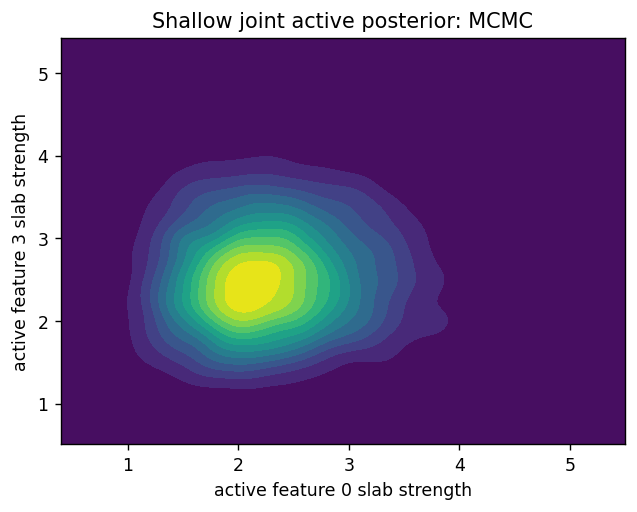

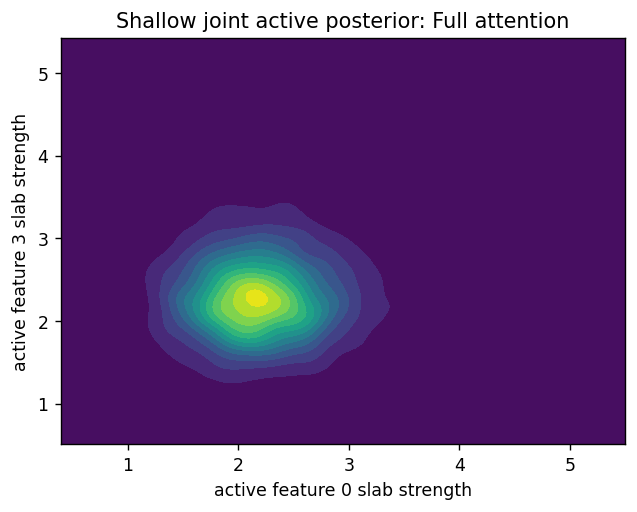

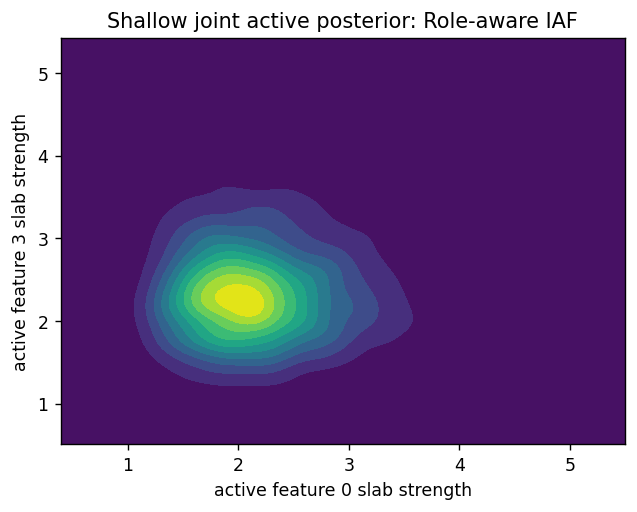

In [12]:
def active_pair_draws(decoder, xi, active_idx=(0, 3)):
    draws = bm.selection_draws(decoder, xi)
    idx = torch.as_tensor(active_idx, device=xi.device, dtype=torch.long)
    active = draws["active"].index_select(1, idx).all(dim=1)
    strength = draws["slab_strength"].index_select(1, idx)
    return strength[active].detach().cpu().numpy()


density_sets = {
    "MCMC": active_pair_draws(reference_model.decoder, reference_xi),
    **{
        label: active_pair_draws(
            out["model"].decoder,
            out["final"]["xi"],
        )
        for label, out in shallow_runs.items()
    },
}

all_draws = np.vstack([x for x in density_sets.values() if len(x) >= 10])
pad = 0.08 * np.maximum(all_draws.max(axis=0) - all_draws.min(axis=0), 1e-3)
x_grid = np.linspace(all_draws[:, 0].min() - pad[0], all_draws[:, 0].max() + pad[0], 140)
y_grid = np.linspace(all_draws[:, 1].min() - pad[1], all_draws[:, 1].max() + pad[1], 140)
xx, yy = np.meshgrid(x_grid, y_grid)
grid = np.vstack([xx.ravel(), yy.ravel()])

for label, values in density_sets.items():
    if len(values) < 10:
        print(f"{label}: only {len(values)} jointly active draws; density skipped.")
        continue
    kde = gaussian_kde(values.T)
    zz = kde(grid).reshape(xx.shape)

    plt.figure(figsize=(5.2, 4.2))
    plt.contourf(xx, yy, zz, levels=12)
    plt.xlabel("active feature 0 slab strength")
    plt.ylabel("active feature 3 slab strength")
    plt.title(f"Shallow joint active posterior: {label}")
    plt.tight_layout()
    plt.show()